In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import skimage as sk
import scipy as scipy


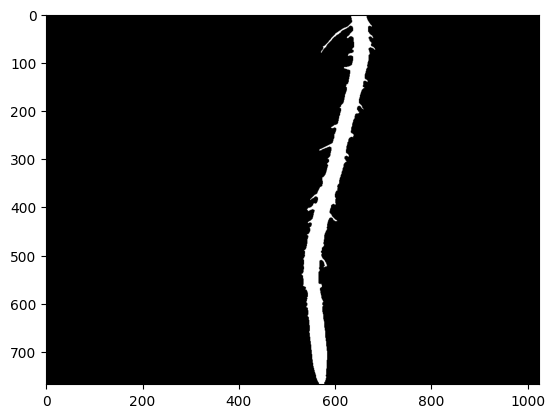

In [10]:
# import image
image_path = '/Users/antoantony/9-30/KO/KO 10 um T0/KO 10 um_6.bmp'
image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# turn it black/white
_, mask = cv2.threshold(image_gray, 110, 255, cv2.THRESH_BINARY_INV)

# 4x4 kernel with adaptive threshold (this actually seems to make it worse, so maybe ignore this part)
# kernel4x4 = np.ones((4,4), np.uint8)
# adapt = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 35, 8)
# # The last two numbers are the block size and the constant subtracted from the mean, respectively. You can adjust these parameters to see how they affect the result.
# adaptive_thresholded = cv2.morphologyEx(adapt, cv2.MORPH_OPEN, kernel4x4)

# connected component
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])  # Skip the background label

CC_mask = np.zeros_like(mask)
CC_mask[labels == largest_label] = 255

# Morphological closing to fill holes
kernel7x7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
closed_mask = cv2.morphologyEx(CC_mask, cv2.MORPH_CLOSE, kernel7x7)

contour, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_closed_contour = np.zeros_like(closed_mask)
cv2.drawContours(mask_closed_contour, contour, -1, 255, -1)

plt.imshow(mask_closed_contour, cmap='gray')
plt.show()

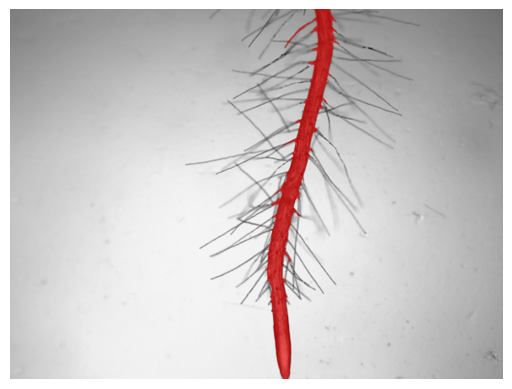

In [11]:
# Create overlay
img_rgb = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)
mask_rgb = cv2.cvtColor(mask_closed_contour, cv2.COLOR_GRAY2RGB)

overlay = img_rgb.copy()
overlay[mask_closed_contour == 255] = [255, 0, 0]  # Red color for the mask area

alpha = 0.4  # Transparency factor
final_overlay = cv2.addWeighted(img_rgb, alpha, overlay, 1 - alpha, 0)

plt.imshow(final_overlay)
plt.axis('off')
plt.show()
# print(contour)

Number of connected components: 319


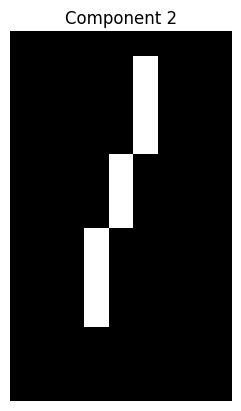

Component 2, length: 10.83 pixels, 
           length: 36.75 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 8,
           diag neighbors: 2"
        


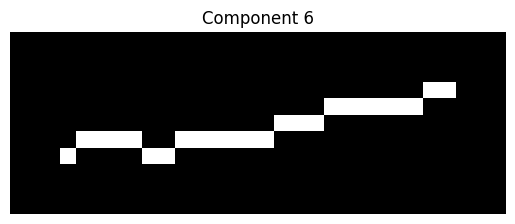

Component 6, length: 25.49 pixels, 
           length: 86.49 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2],
           ortho neighbors: 17,
           diag neighbors: 6"
        


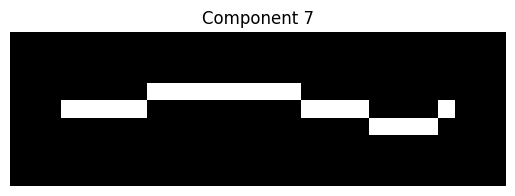

Component 7, length: 23.66 pixels, 
           length: 80.28 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2],
           ortho neighbors: 18,
           diag neighbors: 4"
        


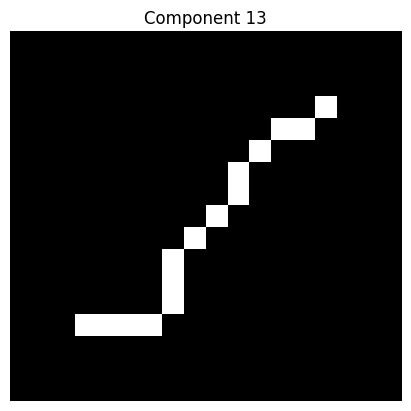

Component 13, length: 16.90 pixels, 
           length: 57.35 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2],
           ortho neighbors: 7,
           diag neighbors: 7"
        


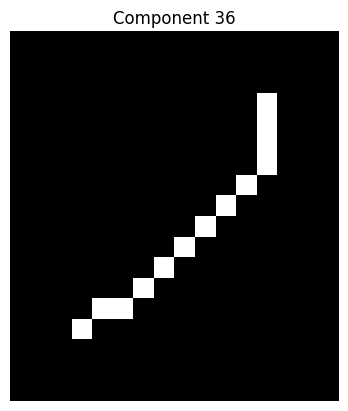

Component 36, length: 15.31 pixels, 
           length: 51.97 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 4,
           diag neighbors: 8"
        


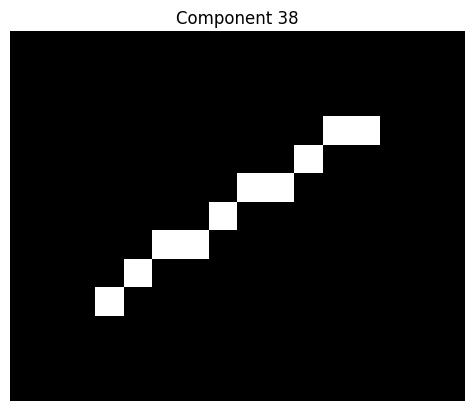

Component 38, length: 11.49 pixels, 
           length: 38.98 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [2, 1, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 3,
           diag neighbors: 6"
        


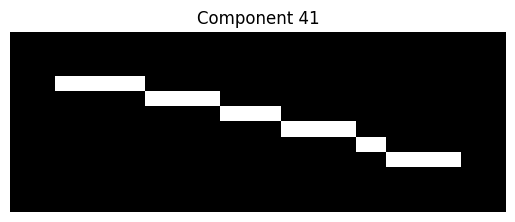

Component 41, length: 28.07 pixels, 
           length: 95.26 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 21,
           diag neighbors: 5"
        


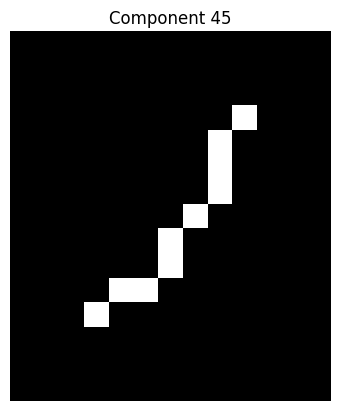

Component 45, length: 11.07 pixels, 
           length: 37.57 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 4,
           diag neighbors: 5"
        


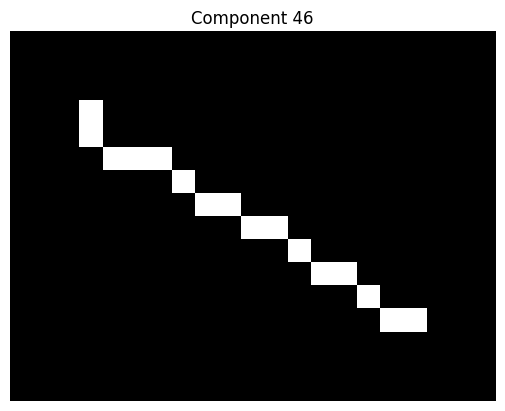

Component 46, length: 18.31 pixels, 
           length: 62.15 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 7,
           diag neighbors: 8"
        


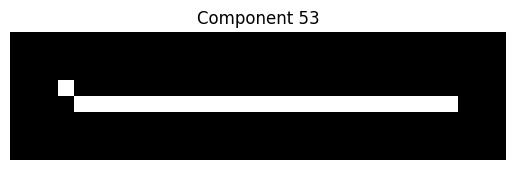

Component 53, length: 24.41 pixels, 
           length: 82.85 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 23,
           diag neighbors: 1"
        


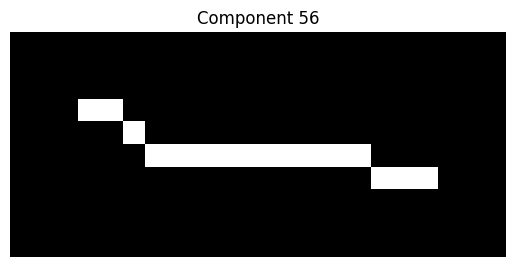

Component 56, length: 16.24 pixels, 
           length: 55.12 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 12,
           diag neighbors: 3"
        


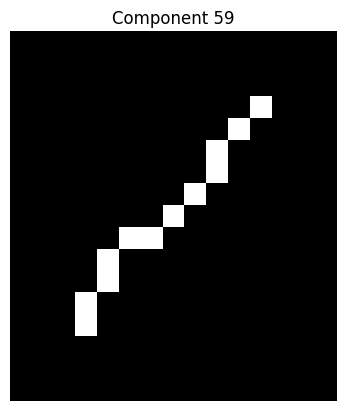

Component 59, length: 13.90 pixels, 
           length: 47.17 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 4,
           diag neighbors: 7"
        


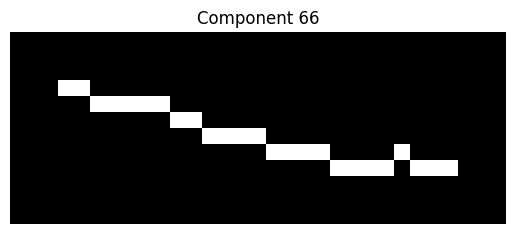

Component 66, length: 26.90 pixels, 
           length: 91.29 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 17,
           diag neighbors: 7"
        


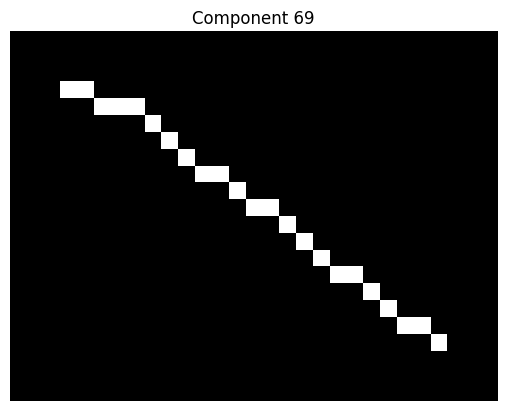

Component 69, length: 28.21 pixels, 
           length: 95.75 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 7,
           diag neighbors: 15"
        


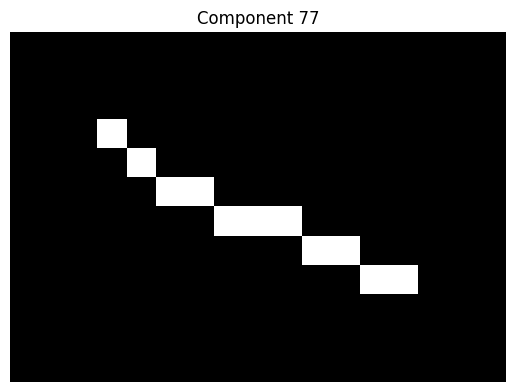

Component 77, length: 12.07 pixels, 
           length: 40.96 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 5,
           diag neighbors: 5"
        


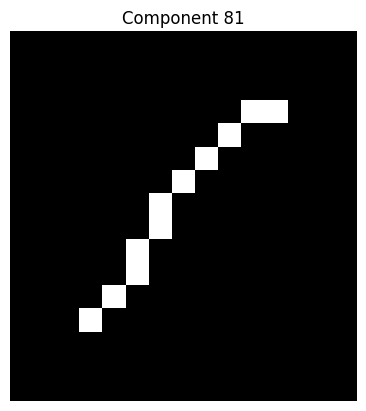

Component 81, length: 12.90 pixels, 
           length: 43.78 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 3,
           diag neighbors: 7"
        


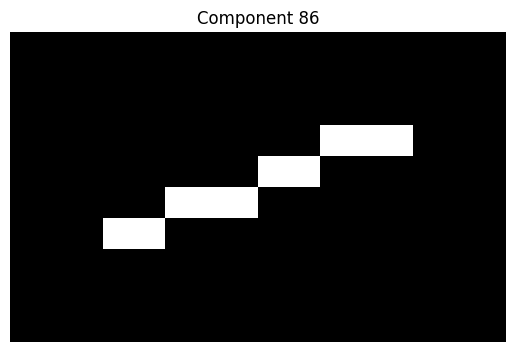

Component 86, length: 10.24 pixels, 
           length: 34.76 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [2, 2, 1, 2, 2, 2, 2, 2, 1, 2],
           ortho neighbors: 6,
           diag neighbors: 3"
        


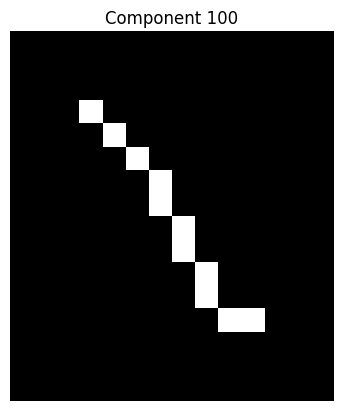

Component 100, length: 12.49 pixels, 
           length: 42.37 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 4,
           diag neighbors: 6"
        


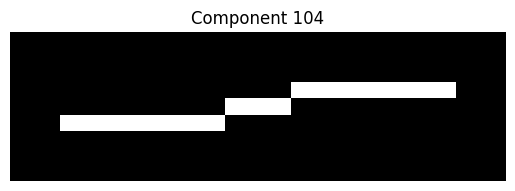

Component 104, length: 23.83 pixels, 
           length: 80.86 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2],
           ortho neighbors: 21,
           diag neighbors: 2"
        


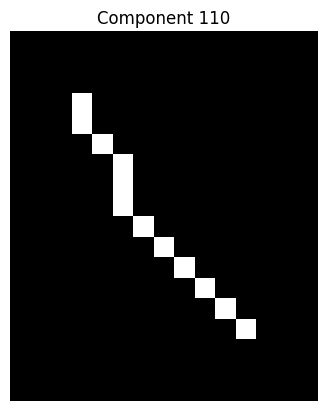

Component 110, length: 14.31 pixels, 
           length: 48.58 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 3,
           diag neighbors: 8"
        


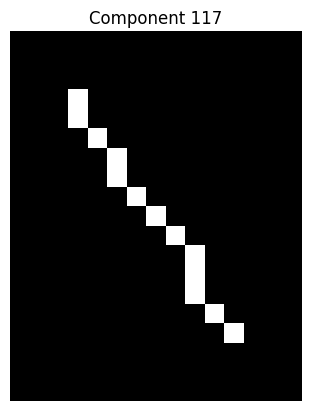

Component 117, length: 15.31 pixels, 
           length: 51.97 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 4,
           diag neighbors: 8"
        


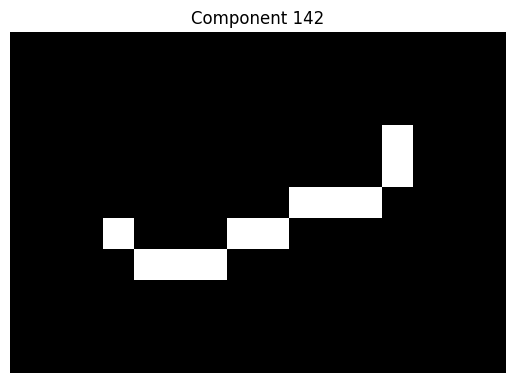

Component 142, length: 11.66 pixels, 
           length: 39.56 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2],
           ortho neighbors: 6,
           diag neighbors: 4"
        


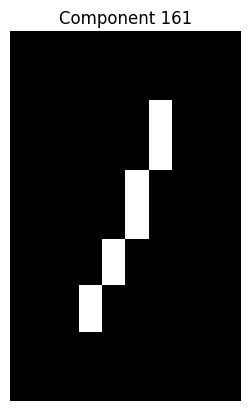

Component 161, length: 10.24 pixels, 
           length: 34.76 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 6,
           diag neighbors: 3"
        


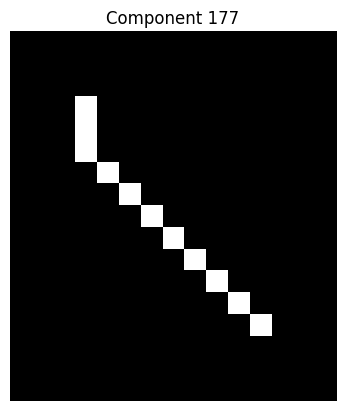

Component 177, length: 13.31 pixels, 
           length: 45.18 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 2,
           diag neighbors: 8"
        


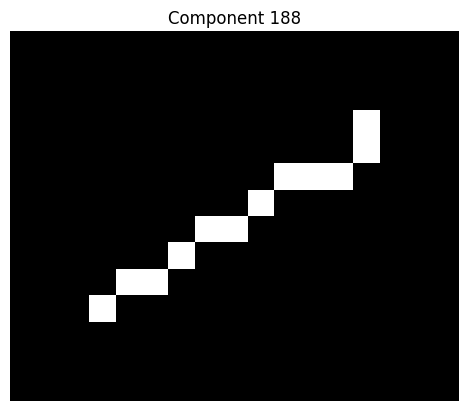

Component 188, length: 13.49 pixels, 
           length: 45.76 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 5,
           diag neighbors: 6"
        


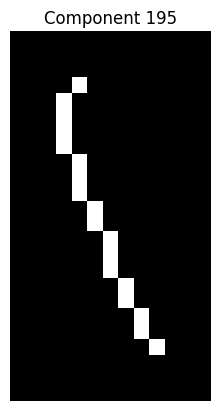

Component 195, length: 19.90 pixels, 
           length: 67.53 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 10,
           diag neighbors: 7"
        


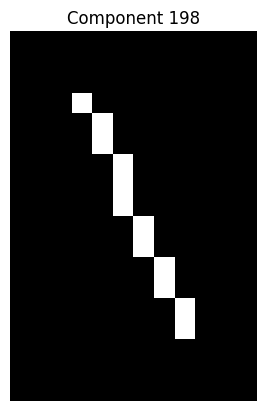

Component 198, length: 13.07 pixels, 
           length: 44.36 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 6,
           diag neighbors: 5"
        


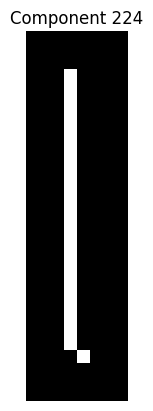

Component 224, length: 22.41 pixels, 
           length: 76.07 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 21,
           diag neighbors: 1"
        


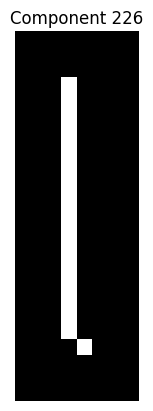

Component 226, length: 17.41 pixels, 
           length: 59.10 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 16,
           diag neighbors: 1"
        


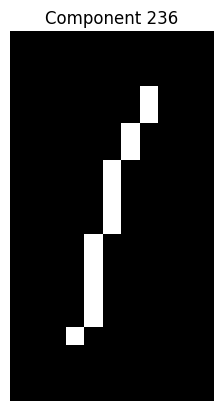

Component 236, length: 14.66 pixels, 
           length: 49.74 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 9,
           diag neighbors: 4"
        


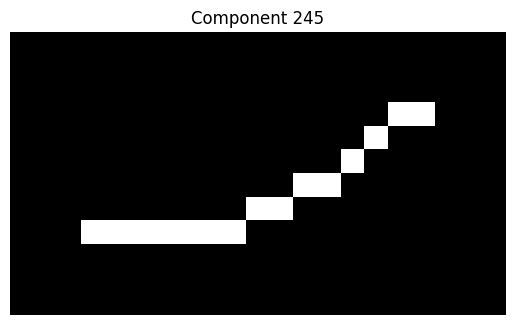

Component 245, length: 16.07 pixels, 
           length: 54.54 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2],
           ortho neighbors: 9,
           diag neighbors: 5"
        


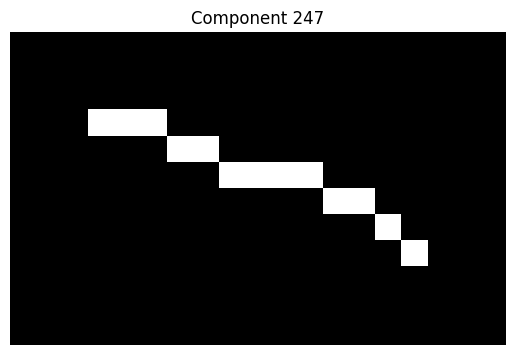

Component 247, length: 14.07 pixels, 
           length: 47.75 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 7,
           diag neighbors: 5"
        


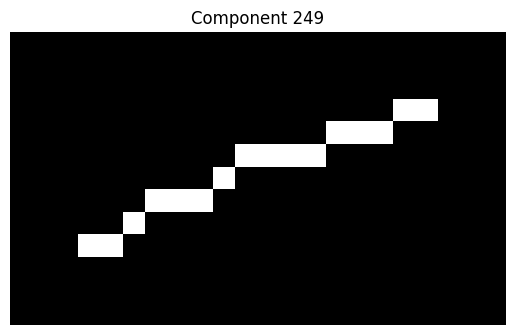

Component 249, length: 17.49 pixels, 
           length: 59.34 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2],
           ortho neighbors: 9,
           diag neighbors: 6"
        


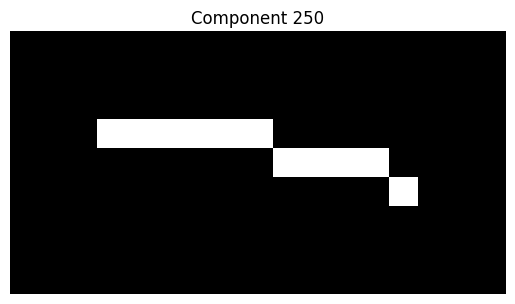

Component 250, length: 10.83 pixels, 
           length: 36.75 microns, 
           endpoints: 2, 
           branchpoints: 0,
           degrees: [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1],
           ortho neighbors: 8,
           diag neighbors: 2"
        


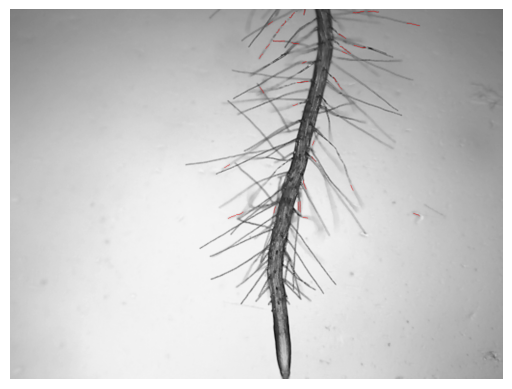

In [17]:
# Create new mask for root hairs using adaptive thresholding
better_adapt = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 8)
root_hair_mask = better_adapt.copy()
expanded_root_mask = cv2.dilate(mask_closed_contour, np.ones((7,7), np.uint8), iterations=1)
root_hair_mask[expanded_root_mask > 0] = 0
# root_hair_mask[mask_closed_contour > 0] = 0

# Skeletonize the root hair mask
skeletonized_hairs = sk.morphology.skeletonize(root_hair_mask // 255)
skeletonized_hairs = (skeletonized_hairs * 255).astype(np.uint8)

# Add main root boundary countour to skeletonized hairs to make a version with contours
skeletonized_hairs_with_contours = skeletonized_hairs.copy()
skeletonized_hairs_with_contours = cv2.drawContours(skeletonized_hairs_with_contours, contour, -1, 255, 1)


skeletonized_hairs_binary = (skeletonized_hairs > 0).astype(np.uint8)
components_masks = sk.measure.label(skeletonized_hairs_binary, connectivity=2)
num_objects = components_masks.max()
print(f"Number of connected components: {num_objects}")

valid_root_hair_masks = []

filtered = 0 # for testing
microscope_conversion_factor = 3.393626769 # variable for user 

for i in range(1, num_objects + 1):
    one_component_mask = (components_masks == i).astype(np.uint8)

    # # for testing 
    # if one_component_mask.sum() < 10:  # Filter out small components
    #     continue
    # if one_component_mask.sum() > 500:  # Filter out large components
    #     continue

    if one_component_mask.sum() == 0:
        continue
    y, x = np.where(one_component_mask > 0)
    adjustment = 3
    h , w = one_component_mask.shape
    y_min = max(0, y.min() - adjustment)
    y_max = min(h-1, y.max() + adjustment)
    x_min = max(0, x.min() - adjustment)
    x_max = min(w-1, x.max() + adjustment)

    cropped_component_mask = one_component_mask[y_min:y_max+1, x_min:x_max+1]

    # make a set of all pixels that make up the component (in tuples)
    coords = np.argwhere(cropped_component_mask > 0)
    root_hair_pixel_set = set(tuple(coordinate) for coordinate in coords)

    # make a kernel that holds the 8 neighbors of a pixel
    neighbors = [
        (-1, -1), (-1, 0), (-1, 1),
        (0, -1),           (0, 1),
        (1, -1), (1, 0), (1, 1)
    ]
    # also make kernels that hold 2 orthogonal neighbors and 2 diagonal neighbors (forward directions only)
    ortho_neighbors = [(0, 1), (1, 0)]
    diag_neighbors = [(1, 1), (1, -1)]

    list_of_degrees = []
    num_ortho_neighbors = 0
    num_diag_neighbors = 0

    # for each pixel in the component:
    for y, x in coords:
        num_neighbors = 0
        # check how many of its neighbors are also in the component by comparing 8-neighbor kernel
        for dy, dx in neighbors:
            if (y + dy, x + dx) in root_hair_pixel_set:
                num_neighbors += 1
        list_of_degrees.append(num_neighbors)
        
        # check how many orthogonal neighbors are in the component by comparing to ortho kernel
        for dy, dx in ortho_neighbors:
            if (y + dy, x + dx) in root_hair_pixel_set:
                num_ortho_neighbors += 1
        # check how many diagonal neighbors are in the component by comparing to diag kernel 
        for dy, dx in diag_neighbors:
            if (y + dy, x + dx) in root_hair_pixel_set:
                num_diag_neighbors += 1


    endpoints = list_of_degrees.count(1)
    branchpoints = sum(1 for x in list_of_degrees if x >= 3)
    # middle_points = list_of_degrees.count(2)

    # calculate the length of the component using ortho and diag neighbors
    length = num_ortho_neighbors + (num_diag_neighbors * np.sqrt(2))
    length_in_microns = length * microscope_conversion_factor

    # filter root hairs that aren't good for measuring 
    if endpoints != 2 or branchpoints:
        continue 
    if length_in_microns > 100 or length_in_microns < 30: 
        continue 

    # need to compare one_component_mask to contour
    coords_of_endpoints = [tuple(coords[i]) for i, d in enumerate(list_of_degrees) if d == 1]
    coords_of_endpoints = [(y + y_min, x + x_min) for y,x in coords_of_endpoints]
    
    coords_of_contour = np.squeeze(contour[0])
    coords_of_contour = set(map(tuple, coords_of_contour))

    endpoint_near_root = False
    for y,x in coords_of_endpoints:
        for n in range(1,8):
            if (x+n, y) in coords_of_contour or (x-n, y) in coords_of_contour:
                endpoint_near_root = True
                break
        if endpoint_near_root:
            break
    
    if not endpoint_near_root:
        continue 

    valid_root_hair_masks.append({
        'id': i,
        'mask': one_component_mask,
        'length': length,
        'length in microns': length_in_microns,
    })
    
    # for testing
    filtered += 1
    plt.imshow(cropped_component_mask, cmap='gray')
    plt.title(f"Component {i}")
    plt.axis('off')
    plt.show()
    print(f'''Component {i}, length: {length:.2f} pixels, 
           length: {length_in_microns:.2f} microns, 
           endpoints: {endpoints}, 
           branchpoints: {branchpoints},
           degrees: {list_of_degrees},
           ortho neighbors: {num_ortho_neighbors},
           diag neighbors: {num_diag_neighbors}"
        ''')

# testing
# print(f"Number of filtered components: {filtered}")



# make final mask

color_root = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)
overlay = color_root.copy()
for i in range(0, len(valid_root_hair_masks)):
    valid_dict = valid_root_hair_masks[i]
    ind_mask = (valid_dict['mask'] * 255).astype(np.uint8)
    overlay[ind_mask == 255] = [255, 0 , 0]

root_hair_overlay = cv2.addWeighted(color_root, 0.2, overlay, 0.8, 0)

plt.imshow(root_hair_overlay, cmap='gray')
plt.axis('off')
plt.show()
# print(coords_of_contour)

In [ ]:
'''I think I need to consider finding alternatives to connectedComponents
It looks like it isn't able to distinguish the individual root hairs. 
Other options Google has recommended:
- cv2.findContours
- cv2.simpleBlobDetector
- skimage.measure.label
- skimage.measure.regionprops
- skan (specifically for skeletons)'''

"I think I need to consider finding alternatives to connectedComponents\nIt looks like it isn't able to distinguish the individual root hairs. \nOther options Google has recommended:\n- cv2.findContours\n- cv2.simpleBlobDetector\n- skimage.measure.label\n- skimage.measure.regionprops\n- skan (specifically for skeletons)"

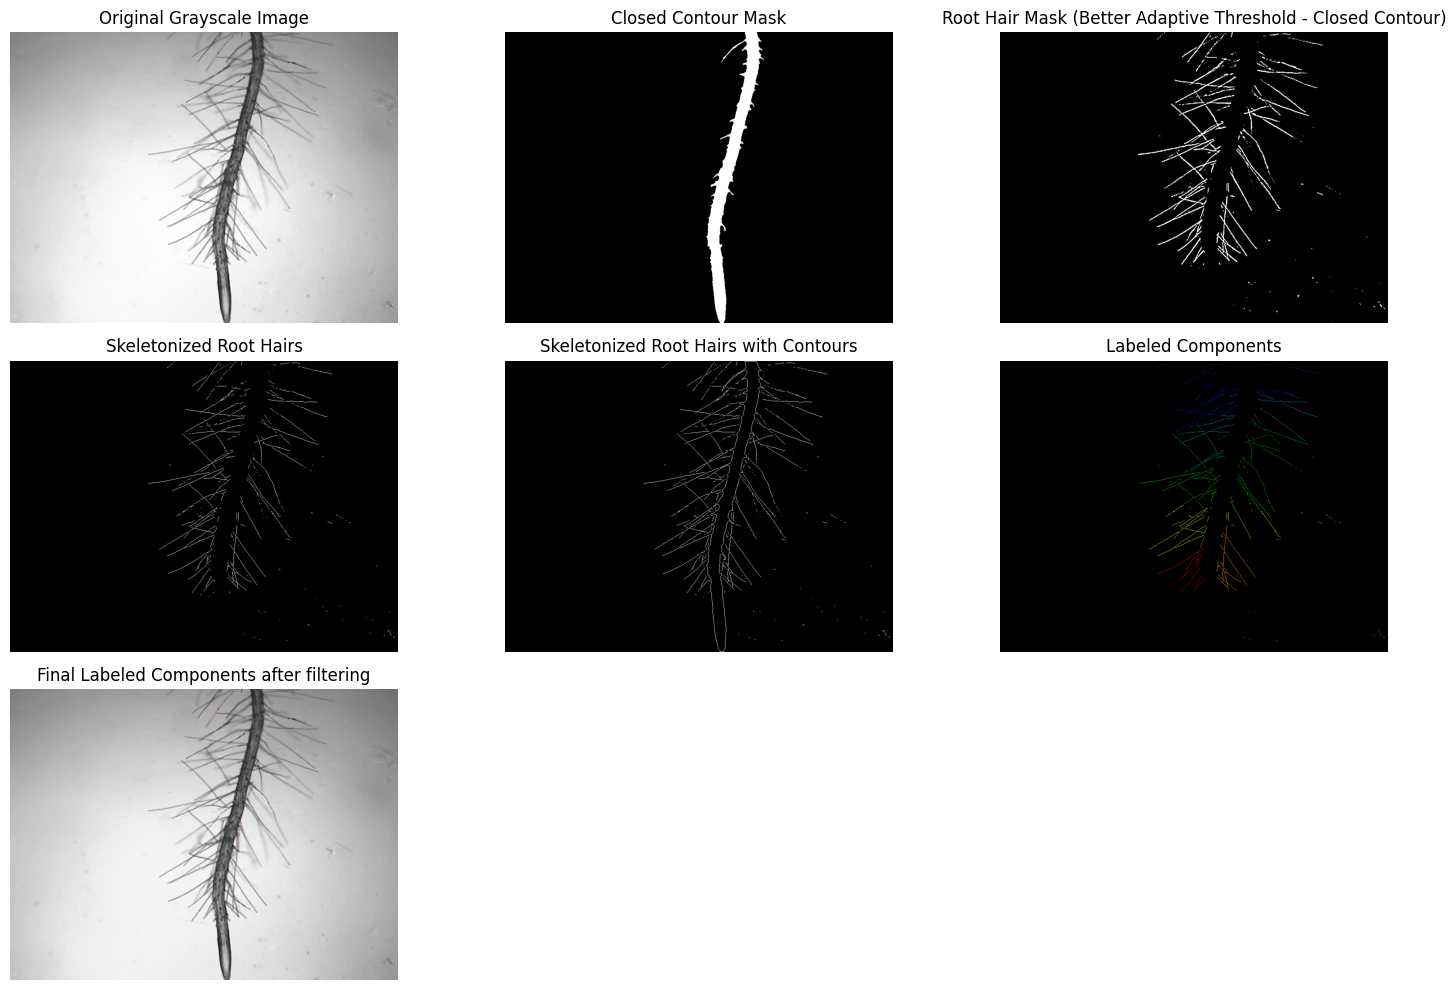

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(15, 10))
ax[0, 0].imshow(image_gray, cmap='gray')
ax[0, 0].set_title('Original Grayscale Image')
ax[0, 0].axis('off')
ax[0, 1].imshow(mask_closed_contour, cmap='gray')
ax[0, 1].set_title('Closed Contour Mask')
ax[0, 1].axis('off')
ax[0, 2].imshow(root_hair_mask, cmap='gray')
ax[0, 2].set_title('Root Hair Mask (Better Adaptive Threshold - Closed Contour)')
ax[0, 2].axis('off')
ax[1, 0].imshow(skeletonized_hairs, cmap='gray')
ax[1, 0].set_title('Skeletonized Root Hairs')
ax[1, 0].axis('off')
ax[1, 1].imshow(skeletonized_hairs_with_contours, cmap='gray')
ax[1, 1].set_title('Skeletonized Root Hairs with Contours')
ax[1, 1].axis('off')
ax[1, 2].imshow(components_masks, cmap='nipy_spectral')
ax[1, 2].set_title('Labeled Components')
ax[1, 2].axis('off')
ax[2, 0].imshow(root_hair_overlay, cmap='nipy_spectral')
ax[2, 0].set_title('Final Labeled Components after filtering')
ax[2, 0].axis('off')
fig.delaxes(ax[2,1])
fig.delaxes(ax[2,2])
plt.tight_layout()
plt.show()